# Generating Points on the Flag Manifold with Chordal-Matern Kernels

## Setup

In [1]:
import rmatqmcpy 
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
from matplotlib import pyplot
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP",verbose_indent=0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch device = %s"%DEVICE)

MPLP['PW'] = 30
MPLP['FS'] = 30
MPLP['COLORS'] a list of length 10
MPLP['LINESTYLES'] a list of length 10
MPLP['MARKERS'] a list of length 12
torch device = cpu


## Kernel Setup

In [2]:
case = "big" # big,small
if case=="small":
    delta = torch.tensor([1,2,3],device=DEVICE,dtype=float)
    n_ref = 2**25
    nu = 3/2
elif case=="big":
    delta = torch.tensor([i for i in range(6)],device=DEVICE,dtype=float)
    n_ref = 2**23
    nu = 9/2
else: raise Exception("invalid case = %s"%case)
delta = delta/torch.linalg.norm(delta)
N = delta.size(-1)
m = delta.unique(return_counts=True)[1]
d = 1/2*(N**2-(m**2).sum())
s = nu+d/2
log2n_max = 10
print("delta = %s"%str(delta))
print("N = %d"%N)
print("m = %s"%str(m))
print("d = %d"%d)
print("nu = %s"%nu)
print("s = %s"%s.item())
print("s/d = %s"%(s/d).item())
print("log2n_max = %s"%log2n_max)
kernel = rmatqmcpy.KernelMaternChordal(delta,nu)
x_ref = rmatqmcpy.genflag_x_eig_ld(2**0,delta,seed=7)
y_ref = rmatqmcpy.genflag_x_eig_ld(n_ref,delta,seed=11)
mean = kernel(x_ref[:,None,:,:],y_ref[None,:,:,:]).mean().item()
print("mean = %.20f"%mean)

delta = tensor([0.0000, 0.1348, 0.2697, 0.4045, 0.5394, 0.6742])
N = 6
m = tensor([1, 1, 1, 1, 1, 1])
d = 15
nu = 4.5
s = 12.0
s/d = 0.8
log2n_max = 10
mean = 0.68474116545467211825


## Transform and Generators

In [3]:
def opt_weights(x, eps=1e-12):
    kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (...,n,n)
    b = torch.ones(kmat.size(-1),device=DEVICE) # (...,n,)
    L = torch.linalg.cholesky(kmat+eps*torch.eye(kmat.size(-1),device=DEVICE),upper=False) # (...,n,n)
    w = torch.cholesky_solve(b[...,None],L,upper=False)[...,0] # (...,n)
    return w/w.sum(-1,keepdim=True)
def genflag_qr_iid_x_opt_w(n, delta, seed=None):
    x = rmatqmcpy.genflag_x_qr_iid(n,delta,seed)
    w = opt_weights(x)
    return x,w
def genflag_qr_ld_x_opt_w(n, delta, seed=None):
    x = rmatqmcpy.genflag_x_qr_ld(n,delta,seed)
    w = opt_weights(x)
    return x,w
def genflag_eig_iid_x_opt_w(n, delta, seed=None):
    x = rmatqmcpy.genflag_x_eig_iid(n,delta,seed)
    w = opt_weights(x)
    return x,w
def genflag_eig_ld_x_opt_w(n, delta, seed=None):
    x = rmatqmcpy.genflag_x_eig_ld(n,delta,seed)
    w = opt_weights(x)
    return x,w

## Optimized Points and Weights

In [4]:
def genflag_opt_x_w(
        n,
        delta,
        seed=None,
        verbose = False, 
        iters = 100,
        eps_kmat = 1e-8,
        verbose_indent = 4,
        ):
    t = delta.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    theta0 = rmatqmcpy.tff_qr(u)
    zerosn = torch.zeros(n,device=DEVICE)
    onesn = torch.ones(n,device=DEVICE)
    eyen = torch.eye(n,device=DEVICE)
    def wce_recip_loss(theta):
        q = agsutil.to_unitary_qr(theta)
        x = torch.einsum("...ij,...j,...kj->...ik",q,delta,q)
        kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (n,n)
        L = torch.linalg.cholesky(kmat+eps_kmat*eyen,upper=False) # (n,n)
        v = torch.linalg.solve_triangular(L,onesn[...,None],upper=False)[...,0]
        return v,x,L
    u,x,L = agsutil.lm_opt(
        f = wce_recip_loss,
        theta0 = theta0,
        ytrue = zerosn,
        iters = iters,
        lam0 = 1e0,
        verbose = verbose,
        verbose_indent = verbose_indent,
        loss_mult = -1,
        # store_data_iters = True,
    )
    # print(data["losses_quantiles"]["50"])
    # print(data["losses_quantiles"]["50"][1:]-data["losses_quantiles"]["50"][:-1])
    w = torch.cholesky_solve(onesn[...,None],L,upper=False)[...,0]
    w = w/w.sum(-1,keepdim=True)
    return x,w
# genflag_opt_x_w(
#     n = 2**4, 
#     delta=delta,
#     seed = 17,
#     verbose = None)

## Convergence on a Test Function

In [5]:
def wce2_plus_kappa(x, w):
    assert x.ndim>=2
    assert x.size(-3)==w.size(-1)
    kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:]) # (...,n,n)
    return torch.einsum("...i,...ij,...j->...",w,kmat,w) # (...,)

In [6]:
genf_funcs = [
    [r"IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$", rmatqmcpy.genflag_x_qr_iid_equal_w], 
    [r"IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$", genflag_qr_iid_x_opt_w], 
    [r"QR LD $\mathcal{X}$ ~ Equal $\boldsymbol{w}$", rmatqmcpy.genflag_x_qr_ld_equal_w], 
    [r"Eig LD $\mathcal{X}$ ~ Equal $\boldsymbol{w}$", rmatqmcpy.genflag_x_eig_ld_equal_w], 
    # [r"QR LD $\mathcal{X}$ ~ Opt $\boldsymbol{w}$", genflag_qr_ld_x_opt_w], 
    # [r"Eig LD $\mathcal{X}$ ~ Opt $\boldsymbol{w}$", genflag_eig_ld_x_opt_w], 
]
if case=="small":
    genf_funcs += [[r"Opt $\mathcal{X}$ ~ Opt $\boldsymbol{w}$", genflag_opt_x_w]]
n = 2**torch.arange(2,log2n_max+1)
trials = 5
seeds = [i for i in range(trials)]
wces = torch.nan*torch.empty((len(genf_funcs),len(n),trials))
t0 = time.perf_counter()
for i,(key,genf_func) in enumerate(genf_funcs):
    print(key)
    for j in range(len(n)):
        print("    n = %d"%n[j])
        t0_ij = time.perf_counter()
        for t in range(trials):
            x,w = genf_func(n=n[j],delta=delta,seed=seeds[t])
            wces[i,j,t] = np.sqrt(max(0,float(wce2_plus_kappa(x,w).cpu()-mean)))
            print("        trial %-10d time %-10.1f wce %-10.1e"%(t,time.perf_counter()-t0,wces[i,j,t]))
        if (time.perf_counter()-t0_ij)/trials>2:
            break

IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$
    n = 4
        trial 0          time 0.0        wce 2.9e-01   
        trial 1          time 0.0        wce 2.9e-01   
        trial 2          time 0.0        wce 2.9e-01   
        trial 3          time 0.0        wce 2.8e-01   
        trial 4          time 0.0        wce 3.1e-01   
    n = 8
        trial 0          time 0.0        wce 2.2e-01   
        trial 1          time 0.0        wce 2.3e-01   
        trial 2          time 0.0        wce 2.2e-01   
        trial 3          time 0.0        wce 1.9e-01   
        trial 4          time 0.0        wce 1.9e-01   
    n = 16
        trial 0          time 0.0        wce 1.3e-01   
        trial 1          time 0.0        wce 1.3e-01   
        trial 2          time 0.0        wce 1.2e-01   
        trial 3          time 0.0        wce 1.2e-01   
        trial 4          time 0.0        wce 1.2e-01   
    n = 32
        trial 0          time 0.0        wce 1.0e-01   
        trial 1    

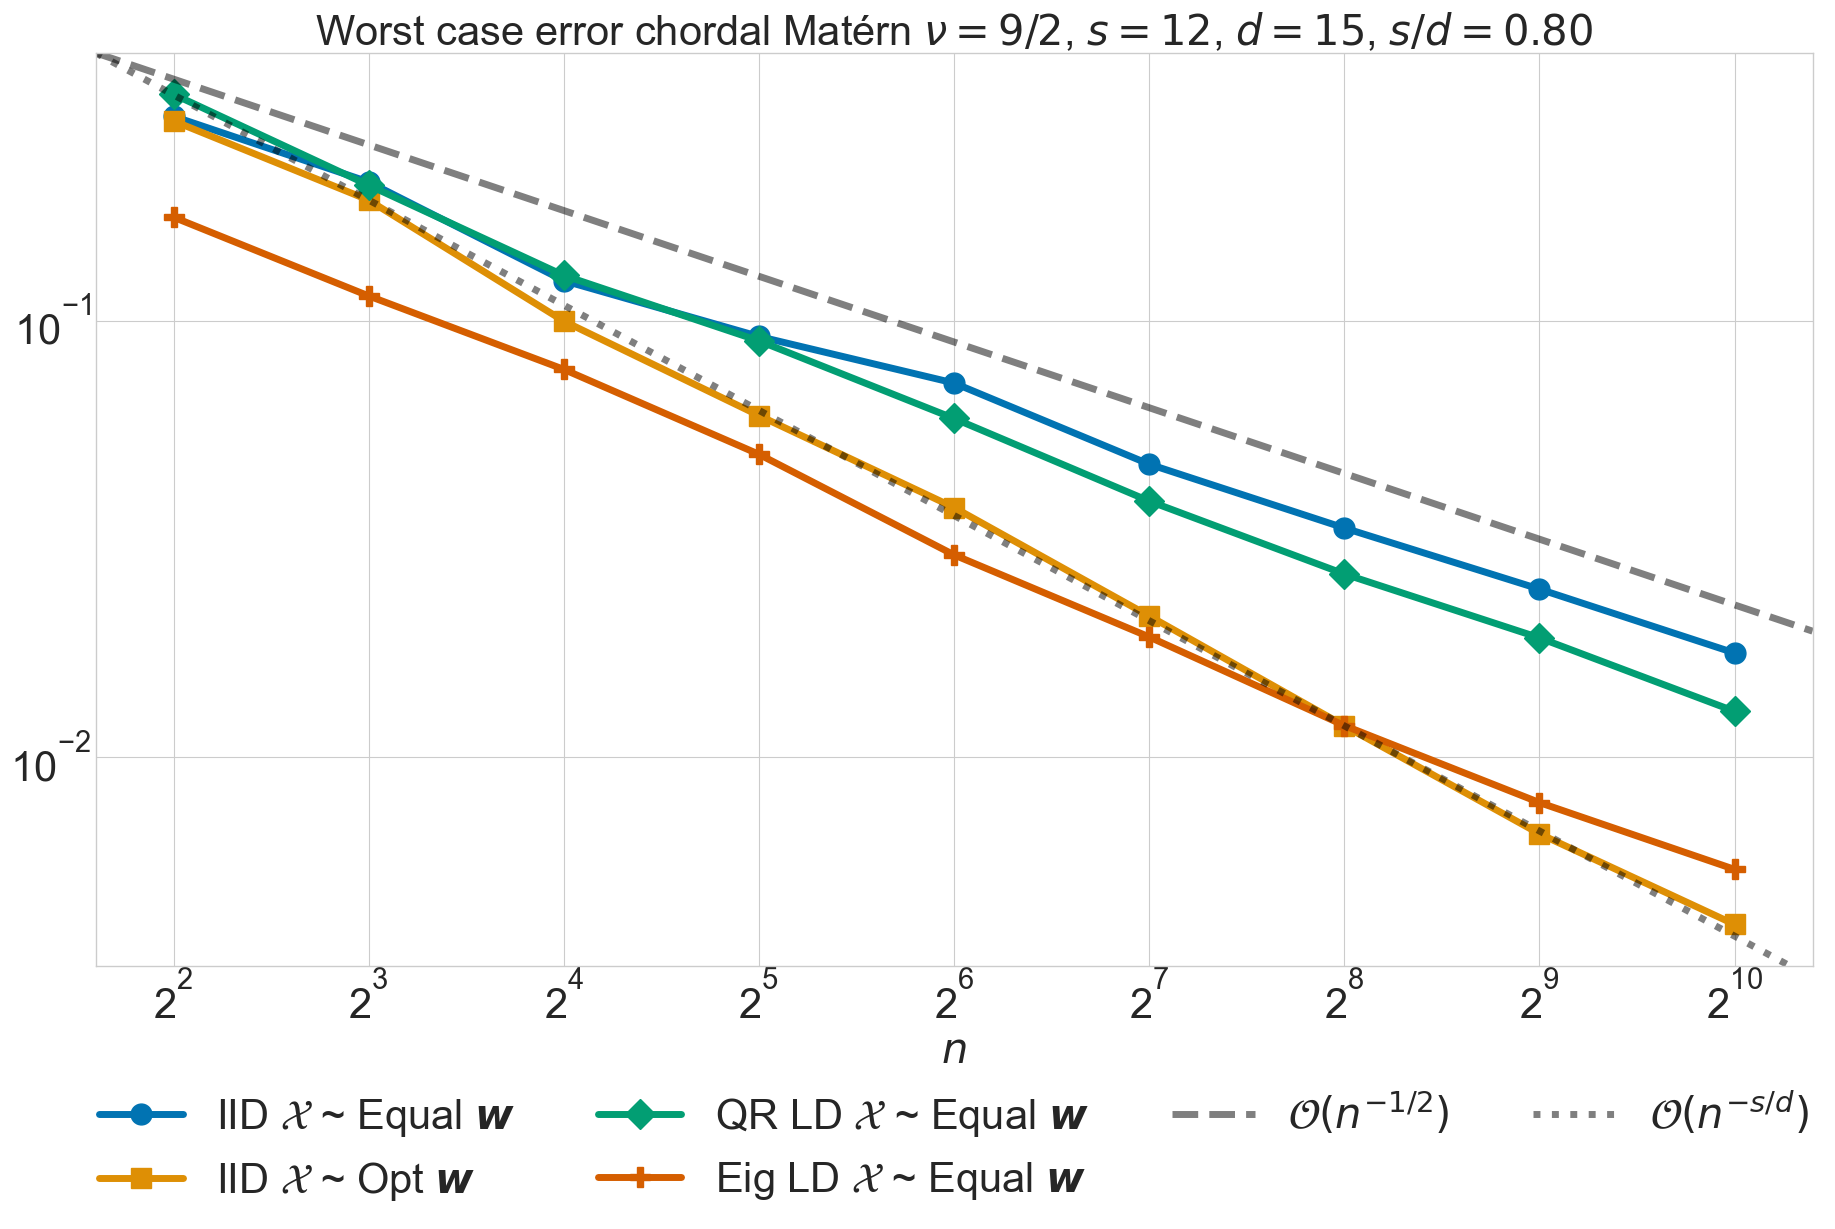

In [7]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(MPLP["PW"]/1.5,MPLP["PW"]/1.5/1.5),sharex=True,sharey=False)
wces_metrics = wces.mean(-1)
for i,(key,_) in enumerate(genf_funcs):
    ax.plot(n,wces_metrics[i],color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key)
ax.set_yscale("log",base=10)
ax.set_xscale("log",base=2)
xmin,xmax = ax.get_xlim()
ymin,ymax = ax.get_ylim()
ax.set_xlim([xmin,xmax])
ax.set_ylim([ymin,ymax])
ax.axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(n^{-1/2})$",linestyle="dashed")
ax.axline([xmin,ymax],[2*xmin,2**(-s/d)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(n^{-s/d})$",linestyle="dotted")
ax.legend(frameon=False,ncols=4,loc="lower center",bbox_to_anchor=(.5,-.3))
assert s==np.inf or s%1 in [0,1/2]
if s==np.inf:
    s_str = r"\infty"
elif s%1==0:
    s_str = r"%d"%s 
elif s%1==1/2:
    s_str = r"%d/2"%(2*s)
ax.set_title(r"Worst case error chordal Matérn "+kernel.nu_str+r", $s = %s$"%s_str+r", $d=%d$"%d+r", $s/d = %.2f$"%(s/d))
ax.set_xlabel(r"$n$")
fig.tight_layout()
fig.savefig("./out/WCE.%s.N%d.d%d.nu%s.png"%(case,N,d,nu))

In [8]:
wces_df = pd.DataFrame(wces.mean(-1).T,columns=[name for (name,_) in genf_funcs])
wces_df['n'] = n
wces_df = wces_df.set_index('n')
print(r"WCEs")
wces_df

WCEs


,IID $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,IID $\mathcal{X}$ ~ Opt $\boldsymbol{w}$,QR LD $\mathcal{X}$ ~ Equal $\boldsymbol{w}$,Eig LD $\mathcal{X}$ ~ Equal $\boldsymbol{w}$
n,,,,
4,0.293583,0.286559,0.329789,0.172502
8,0.207734,0.188736,0.204212,0.113892
16,0.123437,0.099720,0.126924,0.077321
32,0.091981,0.060607,0.089878,0.049414
64,0.071943,0.037317,0.059679,0.029068
128,0.046901,0.021064,0.038612,0.018861
256,0.033499,0.011810,0.026287,0.011820
512,0.024271,0.006679,0.018771,0.007875
1024,0.017330,0.004142,0.012741,0.005537
